# RTDA — float32 vs bfloat16 on AIE-ML

`aie_batch` is built at two precisions from the same ONNX weights. This notebook answers
the only question that matters about the switch: **what does bf16 buy, and what does it
cost?**

Both precisions are compared against **one reference** — `mlp_fp32.onnx`, the physics
model — so the two columns are directly comparable. The reference itself is float32; that
is the point, since it is the thing both designs are trying to reproduce.

| | fp32 | bf16 |
|---|---|---|
| source tree | `src_fp32/` | `src_bf16/` |
| `aie::mmul` microtile | 4x8x4 | 4x8x4 (same → BATCH stays 8) |
| weights | float32 | bfloat16 (stored as `uint16_t` bit patterns) |
| biases | float32 | **float32** (unchanged) |
| accumulator / event mean | float32 | **float32** (`track_accum` widens on load) |

Only the dense stack's data path changes. Everything downstream of the average — the host
dense, the output format, this analysis — is identical, which is what makes the comparison
clean.

**Prerequisite:** run `rtda_reference.ipynb` first, or at least its §3, which writes
`out/golden_onnx_50000.npz`. This notebook loads that rather than rebuilding it.


## 0. Setup


In [1]:
import collections, sys, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.set_printoptions(precision=6, suppress=True, linewidth=120)

REPO = Path.cwd()
while not (REPO / 'model' / 'weights_fp32').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
DATA    = REPO / 'model' / 'weights_fp32'
RESULTS = REPO / 'results'
OUTD    = REPO / 'analysis' / 'out'
OUTD.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# One axes per PNG. Every figure below is a single plot saved on its own, so a
# panel can go into a slide or a doc without being cropped out of a grid.
# save_fig records what it wrote, which is what §9 lists.
# ---------------------------------------------------------------------------
FIGS = []

def save_fig(fig, name):
    p = OUTD / name
    fig.savefig(p, dpi=140, bbox_inches='tight')
    if name not in FIGS:
        FIGS.append(name)
    return p

H, TRACKS_PER_EVENT, SLOTS_PER_EVENT, OUT_DIM, WARMUP = 128, 50, 56, 27, 3

# ---------------------------------------------------------------------------
# THE IMPLEMENTATIONS BEING COMPARED.
#
# One list, used by every table and every plot below. This notebook used to
# hard-code the tuple ('fp32','bf16') in five separate places, so adding a
# third implementation meant finding all five.
#
# All three run the SAME network on the SAME weights (model/weights_fp32/,
# verified identical to 5e-09) against the SAME stimulus. The only thing that
# differs is the arithmetic, which is what makes the comparison meaningful.
# ---------------------------------------------------------------------------
IMPLS = ('aie_fp32', 'aie_bf16', 'pl_fixed')
LABEL = {'aie_fp32': 'AIE-ML fp32', 'aie_bf16': 'AIE-ML bf16',
         'pl_fixed': 'FPGA fixed<16,3>'}
COL   = {'aie_fp32': 'tab:blue', 'aie_bf16': 'tab:red', 'pl_fixed': 'tab:purple'}
# Which implementations the slot-exact reference below describes. It models the
# AIE graph specifically -- 56 slots per event with 6 of them padding, a roll
# carry that survives event boundaries -- so it is not a reference for the PL
# design, which streams one track at a time and pads nothing.
SLOT_EXACT = {'aie_fp32': True, 'aie_bf16': True, 'pl_fixed': False}
# Where each one's runs live, and which simulator/target names it can have.
IMPL_DIR = {i: RESULTS / i for i in IMPLS}

Wo = np.loadtxt(DATA / 'output_weights.txt').astype(np.float64).reshape(H, OUT_DIM)
Bo = np.loadtxt(DATA / 'output_bias.txt').astype(np.float64)
# Applied HERE, to every implementation's 128-wide mean, rather than on-chip by
# each of them -- one copy of this arithmetic, so a difference in the table is a
# difference in the network and not in how someone projected it.
out27 = lambda m: np.asarray(m) @ Wo + Bo      # host convention: y = mean @ W + B

# THE ORDERING DEPENDENCY, stated rather than asserted.
#
# rtda_reference.ipynb §3 runs the ONNX model over all 50,000 tracks and writes
# this file; every accuracy number below is scored against it. This notebook
# does NOT regenerate it -- that is a full onnxruntime pass and duplicating it
# here would give two copies of the reference that could disagree.
#
# A bare `assert` used to raise here, and the traceback buried the one sentence
# that mattered. Clearing analysis/out/ deletes this file along with the
# figures, so "I cleared out/ and ran this one first" is the normal way to
# arrive here, not an exotic one.
REF_NPZ = OUTD / 'golden_onnx_50000.npz'
if not REF_NPZ.exists():
    raise SystemExit(
        f"\n  MISSING: {REF_NPZ.relative_to(REPO)}\n"
        f"\n  This notebook scores everything against the ONNX reference, and does not\n"
        f"  build it. Run rtda_reference.ipynb first -- section 3, 'The 50,000-track\n"
        f"  reference' -- then re-run this notebook from the top.\n"
        f"\n  analysis/out/ holds that file as well as the figures, so clearing the\n"
        f"  directory removes it. Regenerate it -- do not restore an old copy: it is\n"
        f"  scored against by every number here and a stale one is silently wrong.\n")
_g = np.load(REF_NPZ)
REF_PT   = _g['per_track'].astype(np.float64)          # (1000, 50, 128)
REF27    = out27(REF_PT.mean(1))                       # all 50 tracks
REF27_W  = out27(REF_PT[:, WARMUP:].mean(1))           # tracks 3..49
N_EVENTS = REF_PT.shape[0]
FS       = np.abs(REF27).max()

print(f'reference : {REF_NPZ.name}  {N_EVENTS} events')
print(f'            27 outputs, full scale (largest |value|) = {FS:.5f}')
print(f'            with/without warm-up differ by {np.abs(REF27-REF27_W).max():.3e}'
      f'  <- the roll convention, present in BOTH precisions')

# ---------------------------------------------------------------------------
# THE SECOND REFERENCE, and the reason the hardware rows used to read "n/a".
#
# REF27 and REF27_W are both the ONNX, which rolls CIRCULARLY inside an event.
# The AIE streams, and its accumulator averages all 50 tracks because it has no
# way to skip the contaminated head. So NEITHER circular column can measure its
# arithmetic: the WITH column is dominated by the roll convention, and the
# WITHOUT column needs per-track taps that the system build does not wire out.
#
# It never needed per-track taps, only a reference in its own convention.
# rtda_ref.hw_golden() is the slot-exact model of what the array physically
# computes -- 56 slots per event, 6 of them padding, a roll carry that is never
# reset and crosses event boundaries, one leading flush event -- evaluated in
# full fp32. Score an AIE run against THAT and the convention cancels on both
# sides; what is left is arithmetic, over 1000 events instead of 5.
#
# This is the same array sim_events.py already stores as 'golden' in every
# simulation npz (verified equal to 9.4e-12). Hardware simply never had one.
from model import rtda_ref as R                                    # noqa: E402

REF27_HW = out27(R.hw_golden(_g['tracks'].astype(np.float64))[0])
print(f'            slot-exact streaming reference built (rtda_ref.hw_golden, fp32);')
print(f'            it sits {np.abs(REF27_HW - REF27).max():.3e} from the circular ONNX'
      f'  <- the same convention, from the other side')


reference : golden_onnx_50000.npz  1000 events
            27 outputs, full scale (largest |value|) = 0.08568
            with/without warm-up differ by 1.556e-02  <- the roll convention, present in BOTH precisions


            slot-exact streaming reference built (rtda_ref.hw_golden, fp32);
            it sits 1.273e-02 from the circular ONNX  <- the same convention, from the other side


## 1. What ran

Everything found on disk. A precision needs at least one simulation (for the per-track
taps) and ideally the hardware run.


In [2]:
def load_sim(path):
    d = np.load(path)
    nev = int(d['n_events'])
    spe = int(d['slots_per_event']) if 'slots_per_event' in d else SLOTS_PER_EVENT
    off = int(d['flush_slots']) if 'flush_slots' in d else 0
    r = {'file': path.name, 'n_events': nev, 'mean': d['measured'].astype(np.float64)}
    if 's2_out' in d:
        a = d['s2_out'].astype(np.float64)
        if len(a) >= off + nev * spe:
            r['per_track'] = a[off:off+nev*spe].reshape(nev, spe, H)[:, :TRACKS_PER_EVENT, :]
    return r

def load_hw(d):
    d = Path(d)
    f = d / 'track_means_all.txt'
    if not f.exists():
        return None
    with f.open() as fh:
        n_ev, n_col = (int(x) for x in fh.readline().split())
    info = {}
    ri = d / 'run_info.txt'
    if ri.exists():
        for line in ri.read_text().splitlines():
            if '=' in line:
                k, v = line.split('=', 1)
                try:    info[k] = float(v)
                except ValueError: info[k] = v
    return {'file': f.name, 'n_events': n_ev,
            'mean': np.loadtxt(f, skiprows=1).reshape(n_ev, n_col), 'info': info}

# DISCOVER the runs, never hard-code file names. sim_events.py writes
#   sim_<sim>_<precision>_<N>ev_<T>tr.npz
# but older runs predate the precision tag and are named sim_<sim>_<N>ev_<T>tr.npz.
# Reading the precision out of the npz (with a filename fallback) means a clean
# rebuild, a legacy file, or a mix of both all work.
def discover(simout):
    # results/<impl>/sim/ now holds only that implementation's runs, so the
    # precision no longer has to be sniffed out of the file -- the directory
    # says it. Everything lands under the key 'any'.
    found = collections.defaultdict(dict)
    for f in sorted(simout.glob('sim_*ev_*tr.npz')):
        d = np.load(f)
        sim = str(d['sim']) if 'sim' in d else ('x86' if '_x86_' in f.name else 'aie')
        nev = int(d['n_events'])
        key = ('s2_out' in d, nev == 5, nev)   # prefer per-track taps, then ~5 events
        cur = found['any'].get(sim)
        if cur is None or key > cur[0]:
            found['any'][sim] = (key, f)
    return {p: {s: load_sim(v[1]) for s, v in dd.items()} for p, dd in found.items()}

# results/<impl>/{sim,hw,hw_emu}/ -- one layout for every implementation.
RUNS = collections.defaultdict(dict)
for impl in IMPLS:
    simdir = IMPL_DIR[impl] / 'sim'
    if simdir.is_dir():
        # AIE sims are npz written by sim_events.py; the PL sim writes the same
        # track_means_all.txt the boards write, so try both.
        for sim, r in discover(simdir).get('any', {}).items():
            RUNS[impl][sim] = r
        flat = load_hw(simdir)
        if flat:
            RUNS[impl]['sim'] = flat
    for tgt in ('hw', 'hw_emu'):
        r = load_hw(IMPL_DIR[impl] / tgt)
        if r:
            RUNS[impl][tgt] = r

SIMS = ('x86', 'aie', 'sim', 'hw_emu', 'hw')
for impl in IMPLS:
    print(f'{LABEL[impl]}:')
    if not RUNS[impl]:
        print('    -- nothing found')
    for sim in SIMS:
        r = RUNS[impl].get(sim)
        if r is None:
            continue
        pt = ' + per-track' if 'per_track' in r else ''
        wu = r.get('info', {}).get('warmup')
        wus = f'  warmup={int(wu)}' if wu is not None else ''
        print(f'    {sim:6s} {r["n_events"]:5d} events{pt}   ({r["file"]}){wus}')


AIE-ML fp32:
    x86        5 events + per-track   (sim_x86_fp32_5ev_250tr.npz)
    aie        5 events + per-track   (sim_aie_fp32_5ev_250tr.npz)
    hw      1000 events   (track_means_all.txt)  warmup=0
AIE-ML bf16:
    x86        5 events + per-track   (sim_x86_bf16_5ev_250tr.npz)
    aie        5 events + per-track   (sim_aie_bf16_5ev_250tr.npz)
    hw      1000 events   (track_means_all.txt)  warmup=0
FPGA fixed<16,3>:
    sim     1000 events   (track_means_all.txt)  warmup=3
    hw      1000 events   (track_means_all.txt)  warmup=3


## 2. Accuracy — the 27 outputs vs the ONNX golden

The deliverable is the 27-dim output after the average and the host-side dense. Two
conventions, because the roll-concat differs from the reference by construction:

- **with warm-up** — the mean over all 50 tracks, which is what the hardware emits;
- **without warm-up** — tracks 3..49 only. Needs per-track data, so simulation only.

Tracks 0-2 of every event use the streaming roll rather than the reference's circular one.
That difference is present in *both* precisions and is not an arithmetic error, so the
without-warm-up column is the one that isolates precision.


In [3]:
# WHICH COLUMN a run belongs in is decided by how it was produced, never
# guessed. A run whose kernel already averaged tracks 3..49 (the PL flow takes
# warmup as a runtime argument) is a WITHOUT-warm-up number; comparing it
# against the all-50 reference would report the roll convention, 1.5e-02, as if
# it were arithmetic error of 3e-04.
#
# The third column is the slot-exact one. An all-50 AIE mean has no honest
# circular column at all, which is why hardware used to read n/a twice over.
rows = []
for impl in IMPLS:
    for sim in SIMS:
        r = RUNS[impl].get(sim)
        if r is None:
            continue
        n = r['n_events']
        wu = int(r.get('info', {}).get('warmup', 0))
        e_all = e_w = e_hw = None
        if wu >= WARMUP:
            e_w = np.abs(out27(r['mean']) - REF27_W[:n]).max()
        else:
            e_all = np.abs(out27(r['mean']) - REF27[:n]).max()
            if SLOT_EXACT[impl]:
                e_hw = np.abs(out27(r['mean']) - REF27_HW[:n]).max()
        if 'per_track' in r:      # simulation also has the per-track taps
            e_w = np.abs(out27(r['per_track'][:, WARMUP:].mean(1)) - REF27_W[:n]).max()
        rows.append((impl, sim, n, e_all, e_w, e_hw))

print(f'{"implementation":<20s} {"run":>7s} {"events":>7s} '
      f'{"WITH warm-up":>14s} {"WITHOUT warm-up":>17s} {"vs slot-exact":>15s}')
print(f'{"":<20s} {"":>7s} {"":>7s} {"(circular ONNX)":>14s} {"(circular ONNX)":>17s} '
      f'{"(streaming)":>15s}')
print('-' * 86)
for impl, sim, n, a, w, hwe in rows:
    as_ = f'{a:14.3e}' if a is not None else f'{"n/a":>14s}'
    ws  = f'{w:17.3e}' if w is not None else f'{"n/a":>17s}'
    hs  = f'{hwe:15.3e}' if hwe is not None else f'{"n/a":>15s}'
    print(f'  {LABEL[impl]:<18s} {sim:>7s} {n:7d} {as_} {ws} {hs}')
print('-' * 86)
print(f'  {"reference against itself":<26s} {np.abs(REF27-REF27_W).max():14.3e}'
      f'   <- the roll convention alone')

# ---------------------------------------------------------------------------
# ONE run selection, used by every number and every plot from here down.
#
# There used to be two. `BEST` took the run with the SMALLEST error and
# `per_output_err()` took the FIRST run in SIMS order, so the headline printed
# one implementation's absolute error from a 1000-event hardware run beside its
# relative error from a 2-event simulation, labelled with hardware's event
# count. The 2-event run was itself wrong -- `make fastsim` had inherited the
# 100-track hw_emu stimulus, which is testdata Family A (one real event
# repeated) against a Family B reference -- and the selection rule is what
# promoted it to the headline.
#
# Pick by EVENT COUNT, once. A run covering more events cannot be displaced by
# a shorter one, and a broken short run can no longer win by scoring well.
def arithmetic(impl):
    """The run that measures ARITHMETIC for `impl`, and against which reference.

    Two references qualify, and which applies is a property of the run:

      'ONNX 3..49'   the run averaged tracks 3..49, or has per-track taps to do
                     it here. The two roll conventions agree to 4e-06 there.
      'slot-exact'   an all-50 AIE mean, scored against rtda_ref.hw_golden in
                     fp32, which streams and pads exactly as the array does.

    Both cancel the convention and leave arithmetic, so the two are comparable.
    """
    best = None
    for sim in SIMS:
        r = RUNS[impl].get(sim)
        if r is None:
            continue
        n = r['n_events']
        if 'per_track' in r:
            e, ref = out27(r['per_track'][:, WARMUP:].mean(1)) - REF27_W[:n], 'ONNX 3..49'
        elif int(r.get('info', {}).get('warmup', 0)) >= WARMUP:
            e, ref = out27(r['mean']) - REF27_W[:n], 'ONNX 3..49'
        elif SLOT_EXACT[impl]:
            e, ref = out27(r['mean']) - REF27_HW[:n], 'slot-exact'
        else:
            continue
        e = np.abs(e)
        # Hardware wins a tie. The PL native model now covers the same 1000
        # events as the board and is bit-identical to it (0.0), so either is
        # correct -- but a headline that says "sim" reads as though the design
        # was never measured on silicon.
        if best is None or (n, sim == 'hw') > (best['n'], best['sim'] == 'hw'):
            best = {'sim': sim, 'n': n, 'ref': ref, 'worst': e.max(),
                    'per_event': e.max(axis=1), 'per_output': e.max(axis=0)}
    return best

ARITH = {}
for impl in IMPLS:
    a = arithmetic(impl)
    if a is not None:
        ARITH[impl] = a

print()
for impl in IMPLS:
    if impl in ARITH:
        a = ARITH[impl]
        print(f'  {LABEL[impl]:<18s} {a["worst"]:.3e}  ({100*a["worst"]/FS:.3f}% FS, '
              f'{a["sim"]}, {a["n"]} events, vs {a["ref"]})')

if 'aie_bf16' in ARITH and 'pl_fixed' in ARITH:
    nc = min(ARITH['aie_bf16']['n'], ARITH['pl_fixed']['n'])
    b = ARITH['aie_bf16']['per_event'][:nc].max()
    p = ARITH['pl_fixed']['per_event'][:nc].max()
    verb = 'closer to' if p < b else 'further from'
    print(f'\n  Over the same {nc} event(s):  bf16 {b:.3e}   ap_fixed {p:.3e}')
    print(f'  FPGA fixed<16,3> is {b/p:.1f}x {verb} the reference than AIE-ML bf16.')
    print(f"""
  Both are 16 bits per activation. bfloat16 spends 8 of them on an exponent
  covering ~1e38; every activation in this network lives between -1.8 and +1.8.
  ap_fixed<16,3> spends 13 bits on the mantissa of a range that was measured.""")


implementation           run  events   WITH warm-up   WITHOUT warm-up   vs slot-exact
                                     (circular ONNX)   (circular ONNX)     (streaming)
--------------------------------------------------------------------------------------
  AIE-ML fp32            x86       5      6.920e-03         7.534e-07       8.000e-07
  AIE-ML fp32            aie       5      6.920e-03         7.534e-07       8.000e-07
  AIE-ML fp32             hw    1000      1.273e-02               n/a       1.241e-06
  AIE-ML bf16            x86       5      6.816e-03         3.963e-04       3.385e-04
  AIE-ML bf16            aie       5      6.816e-03         3.963e-04       3.385e-04
  AIE-ML bf16             hw    1000      1.307e-02               n/a       8.001e-04
  FPGA fixed<16,3>       sim    1000            n/a         3.539e-04             n/a
  FPGA fixed<16,3>        hw    1000            n/a         3.539e-04             n/a
----------------------------------------------------

### Per output, not just full scale

"% of full scale" divides by the largest of the 27 outputs, which flatters bf16: the
outputs have very different spreads. Judging each against **its own** event-to-event
variation is stricter and more useful — an error comparable to an output's own spread
destroys the information in it.


output spreads (std across 1000 events): 0.00052 .. 0.01523   (29x range)

AIE-ML fp32       : worst output = index 17 at 0.0% of its own spread   (1000 events, vs slot-exact)
AIE-ML bf16       : worst output = index 21 at 11.2% of its own spread   (1000 events, vs slot-exact)
FPGA fixed<16,3>  : worst output = index 21 at 8.0% of its own spread   (1000 events, vs ONNX 3..49)


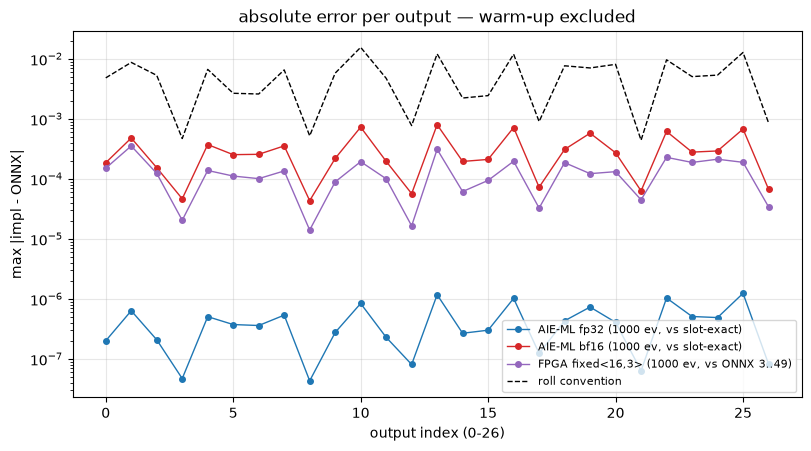

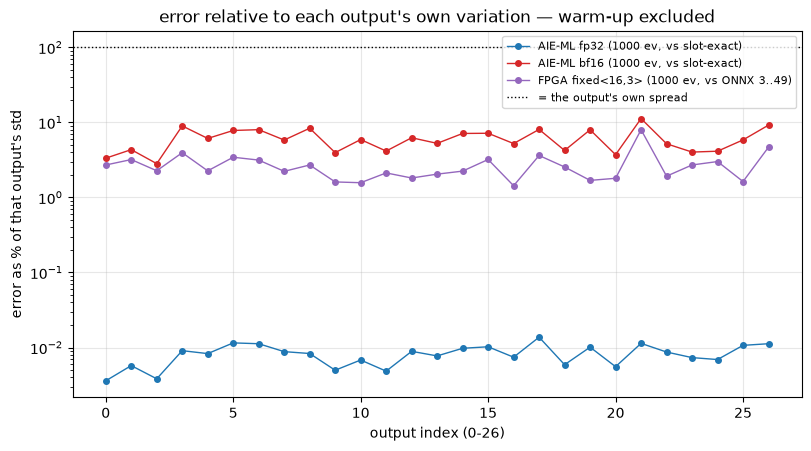

In [4]:
std = REF27_W.std(0)                       # (27,) spread of each output across events
print(f'output spreads (std across {N_EVENTS} events): '
      f'{std.min():.5f} .. {std.max():.5f}   ({std.max()/std.min():.0f}x range)\n')

# ARITH, not a second selection of its own. This cell used to walk SIMS itself
# and take the first hit, which for the PL flow meant the 2-event simulation
# while the headline above quoted the 1000-event board run.
#
# Selected once, plotted twice: the absolute error and the same error scaled by
# each output's own spread are separate figures, one axes each.
series = []
for impl in IMPLS:
    if impl not in ARITH:
        continue
    err = ARITH[impl]['per_output']
    lab = f'{LABEL[impl]} ({ARITH[impl]["n"]} ev, vs {ARITH[impl]["ref"]})'
    series.append((impl, err, lab))
    print(f'{LABEL[impl]:<18s}: worst output = index {int((err/std).argmax())} at '
          f'{100*(err/std).max():.1f}% of its own spread'
          f'   ({ARITH[impl]["n"]} events, vs {ARITH[impl]["ref"]})')

fig, ax = plt.subplots(figsize=(8, 4.4), constrained_layout=True)
for impl, err, lab in series:
    ax.semilogy(err, 'o-', ms=4, lw=1, color=COL[impl], label=lab)
ax.semilogy(np.abs(REF27 - REF27_W).max(axis=0), 'k--', lw=1, label='roll convention')
ax.set_xlabel('output index (0-26)'); ax.set_ylabel('max |impl - ONNX|')
ax.set_title('absolute error per output — warm-up excluded')
ax.legend(fontsize=8); ax.grid(alpha=.3)
save_fig(fig, 'accuracy_per_output_absolute.png')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.4), constrained_layout=True)
for impl, err, lab in series:
    ax.semilogy(100 * err / std, 'o-', ms=4, lw=1, color=COL[impl], label=lab)
ax.axhline(100, color='k', ls=':', lw=1, label="= the output's own spread")
ax.set_xlabel('output index (0-26)'); ax.set_ylabel("error as % of that output's std")
ax.set_title("error relative to each output's own variation — warm-up excluded")
ax.legend(fontsize=8); ax.grid(alpha=.3)
save_fig(fig, 'accuracy_per_output_relative.png')
plt.show()


## 3. Hardware — 1000 events each

Both precisions ran the same 50,000-track stimulus on silicon. Only the with-warm-up
comparison exists here (no per-track taps in the system build), so the absolute level is
dominated by the roll convention in both columns — what to look at is whether bf16 sits
*above* fp32, and by how much.


AIE-ML fp32       : 1000 events   worst 1.273e-02   median 4.149e-03   (warmup=0)
AIE-ML bf16       : 1000 events   worst 1.307e-02   median 4.189e-03   (warmup=0)
FPGA fixed<16,3>  : 1000 events   worst 3.539e-04   median 1.978e-04   (warmup=3)


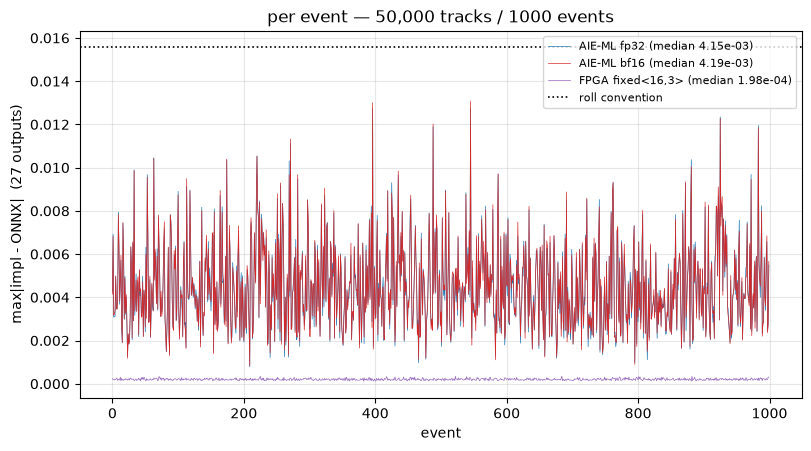

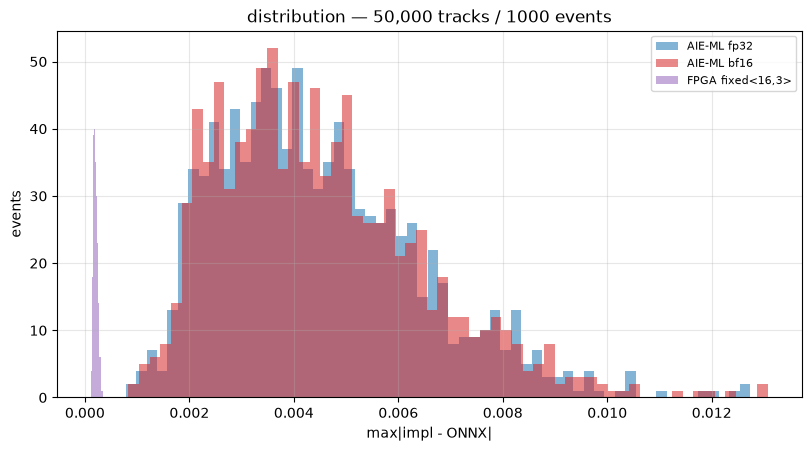

In [5]:
# The largest run each implementation has -- the board where there is one, the
# 1000-event native run for PL. Each is compared against the reference in ITS
# OWN warm-up convention (see the table above for why that is not optional).
series = []
for impl in IMPLS:
    # Longest run, hardware winning any tie -- the PL native model now covers
    # the same 1000 events as the board, and "whichever came first" is not a
    # reason to plot one rather than the other.
    r = max(((RUNS[impl][s], s == 'hw') for s in SIMS if s in RUNS[impl]),
            key=lambda t: (t[0]['n_events'], t[1]), default=(None, False))[0]
    if r is None:
        continue
    n = min(r['n_events'], N_EVENTS)
    wu = int(r.get('info', {}).get('warmup', 0))
    ref = REF27_W if wu >= WARMUP else REF27
    e = np.abs(out27(r['mean'][:n]) - ref[:n]).max(axis=1)
    series.append((impl, e, f'{LABEL[impl]} (median {np.median(e):.2e})'))
    print(f'{LABEL[impl]:<18s}: {n} events   worst {e.max():.3e}   '
          f'median {np.median(e):.3e}   (warmup={wu})')

fig, ax = plt.subplots(figsize=(8, 4.4), constrained_layout=True)
for impl, e, lab in series:
    ax.plot(e, lw=.5, color=COL[impl], label=lab)
ax.axhline(np.abs(REF27-REF27_W).max(), color='k', ls=':', lw=1.2, label='roll convention')
ax.set_xlabel('event'); ax.set_ylabel('max|impl - ONNX|  (27 outputs)')
ax.set_title('per event — 50,000 tracks / 1000 events')
ax.legend(fontsize=8); ax.grid(alpha=.3)
save_fig(fig, 'accuracy_50k_per_event.png')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.4), constrained_layout=True)
for impl, e, _ in series:
    ax.hist(e, bins=60, alpha=.55, color=COL[impl], label=LABEL[impl])
ax.set_xlabel('max|impl - ONNX|'); ax.set_ylabel('events')
ax.set_title('distribution — 50,000 tracks / 1000 events')
ax.legend(fontsize=8); ax.grid(alpha=.3)
save_fig(fig, 'accuracy_50k_distribution.png')
plt.show()


In [6]:
# do the two precisions agree with EACH OTHER on hardware? they share everything but the
# dense data path, so this isolates precision from every other difference
if 'hw' in RUNS['aie_fp32'] and 'hw' in RUNS['aie_bf16']:
    a, b = RUNS['aie_fp32']['hw']['mean'], RUNS['aie_bf16']['hw']['mean']
    n = min(len(a), len(b))
    d = np.abs(out27(a[:n]) - out27(b[:n])).max(axis=1)
    print(f'AIE-ML fp32 vs AIE-ML bf16 on hardware, {n} events (27 outputs)')
    print(f'  worst {d.max():.3e}   median {np.median(d):.3e}   = {100*d.max()/FS:.3f}% of full scale')
    print('\n  This is the pure precision difference: same stimulus, same weights, same')
    print('  roll, same accumulator. Everything else cancels.')
    print('\n  The PL flow cannot be differenced this way -- it uses the same weights but a')
    print('  different decomposition (two 128-wide denses plus an add, rather than one')
    print('  256-wide GEMM), so a direct difference would mix that in with the format.')
    print('  Both are compared against the reference instead.')


AIE-ML fp32 vs AIE-ML bf16 on hardware, 1000 events (27 outputs)
  worst 8.005e-04   median 3.363e-04   = 0.934% of full scale

  This is the pure precision difference: same stimulus, same weights, same
  roll, same accumulator. Everything else cancels.

  The PL flow cannot be differenced this way -- it uses the same weights but a
  different decomposition (two 128-wide denses plus an add, rather than one
  256-wide GEMM), so a direct difference would mix that in with the format.
  Both are compared against the reference instead.


## 4. Performance

`run_info.txt` from each board run, plus the cycle-accurate II from `make report`.


In [7]:
# Throughput. The two AIE numbers come from `make report` (aiesimulator II);
# the PL number is its measured hardware time. They are not the same kind of
# measurement and the table says so rather than putting them in one column.
# Reuse factor, read from the header rather than hardcoded: this text explains
# part of the PL timing and must not drift from what was actually built.
import re as _re
_h = (REPO / 'pl_fixed/pl/src/rtda_fixed.h').read_text()
RF = int(_re.search(r'define\s+RTDA_REUSE_DENSE\s+(\d+)', _h).group(1))

II_NS = {'aie_fp32': 4161.0, 'aie_bf16': 1033.0}   # aiesimulator, `make report`
MACS_PER_TRACK, ITER_PER_EVENT = 264192, 7

perf = {}
for impl in IMPLS:
    r = max((RUNS[impl][s] for s in ('hw', 'hw_emu', 'sim') if s in RUNS[impl]),
            key=lambda x: x['n_events'], default=None)
    info = r['info'] if r else {}
    ii = II_NS.get(impl)
    perf[impl] = dict(
        ii=ii,
        model_ns=(ii * ITER_PER_EVENT / TRACKS_PER_EVENT) if ii else float('nan'),
        # the AIE host reports us_per_track; the PL host reports it too
        hw_ns=float(info.get('us_per_track', float('nan'))) * 1000,
        gops=float(info.get('gops', float('nan'))),
        rtp=float(info.get('rtp_bytes', float('nan'))),
        exec_us=float(info.get('us_execute', info.get('ms_total', float('nan')) * 1000)),
        source=info.get('source', 'hw' if r and 'us_execute' in info else '?'),
        n=r['n_events'] if r else 0,
    )

print(f'{"implementation":<20s} {"II (ns)":>9s} {"ns/track":>11s} {"ns/track":>11s} {"GOP/s":>9s}')
print(f'{"":<20s} {"cyc-acc":>9s} {"cyc-acc":>11s} {"measured":>11s} {"":>9s}')
print('-' * 64)
for impl in IMPLS:
    p = perf[impl]
    ii = f'{p["ii"]:9.0f}' if p['ii'] else f'{"n/a":>9s}'
    mn = f'{p["model_ns"]:11.1f}' if p['ii'] else f'{"n/a":>11s}'
    hn = f'{p["hw_ns"]:11.1f}' if p['hw_ns'] == p['hw_ns'] else f'{"n/a":>11s}'
    gp = f'{p["gops"]:9.0f}' if p['gops'] == p['gops'] else f'{"n/a":>9s}'
    print(f'  {LABEL[impl]:<18s} {ii} {mn} {hn} {gp}')
print('-' * 64)

f, b = perf['aie_fp32'], perf['aie_bf16']
if f['hw_ns'] == f['hw_ns'] and b['hw_ns'] == b['hw_ns']:
    print(f"""
  AIE-ML bf16 vs AIE-ML fp32: {f['ii']/b['ii']:.2f}x in the array (II), but {f['hw_ns']/b['hw_ns']:.2f}x on silicon.
  The gap is data movement -- the DMA and the per-graph.run() host cost do not
  scale with precision, so as the array gets faster they take a bigger share.""")

pl = perf['pl_fixed']
if pl['hw_ns'] == pl['hw_ns'] and b['hw_ns'] == b['hw_ns']:
    print(f"""
  FPGA vs AIE-ML bf16: {pl['hw_ns']/b['hw_ns']:.0f}x slower per track. TWO causes, not one:

  1. Architecture. The PL design runs one track at a time through a chain of
     14 dense layers; the AIE processes 8 tracks per aie::mmul instruction across
     65 compute tiles.
  2. Reuse factor {RF}. Each 128x128 dense is spread over {RF} cycles and so
     builds {16384//RF} multipliers instead of 64. That is a deliberate {RF//256}x
     slowdown, taken to make the design ROUTE -- at RF=256 it placed at 98.87%
     LUT and routing failed (congestion level 6, 469,480 unrouted signals).
     See pl_fixed/RESOURCES.md.

  So of the {pl['hw_ns']/b['hw_ns']:.0f}x, about {RF//256}x is the reuse factor and
  ~{pl['hw_ns']/b['hw_ns']/(RF//256):.0f}x is the architecture. At RF=256 this design
  would be ~{pl['hw_ns']/(RF//256):.0f} ns/track -- still far slower than the AIE, and
  it would not fit.

  None of this affects accuracy: the reuse factor is a scheduling knob and the
  arithmetic is bit-identical at every legal value.""")
elif pl['n']:
    print(f"""
  FPGA timing: no hardware run yet ({pl['n']} events from the native model, which
  measures the host CPU and says nothing about the FPGA). Numbers appear here
  after `make system FLOW=pl_fixed TARGET=hw` and a board run.""")


implementation         II (ns)    ns/track    ns/track     GOP/s
                       cyc-acc     cyc-acc    measured          
----------------------------------------------------------------
  AIE-ML fp32             4161       582.5       615.0       859
  AIE-ML bf16             1033       144.6       244.5      2161
  FPGA fixed<16,3>         n/a         n/a     94793.4       n/a
----------------------------------------------------------------

  AIE-ML bf16 vs AIE-ML fp32: 4.03x in the array (II), but 2.52x on silicon.
  The gap is data movement -- the DMA and the per-graph.run() host cost do not
  scale with precision, so as the array gets faster they take a bigger share.

  FPGA vs AIE-ML bf16: 388x slower per track. TWO causes, not one:

  1. Architecture. The PL design runs one track at a time through a chain of
     14 dense layers; the AIE processes 8 tracks per aie::mmul instruction across
     65 compute tiles.
  2. Reuse factor 1024. Each 128x128 dense is spread over 1

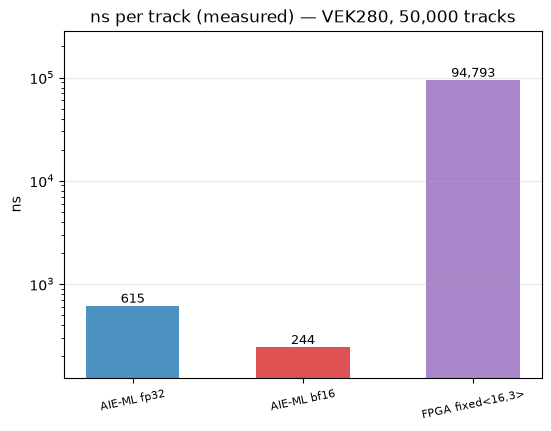

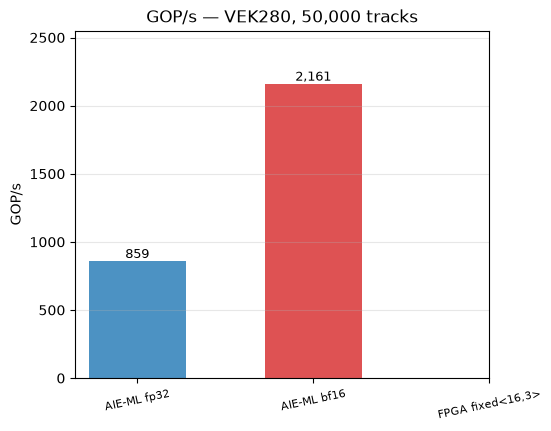

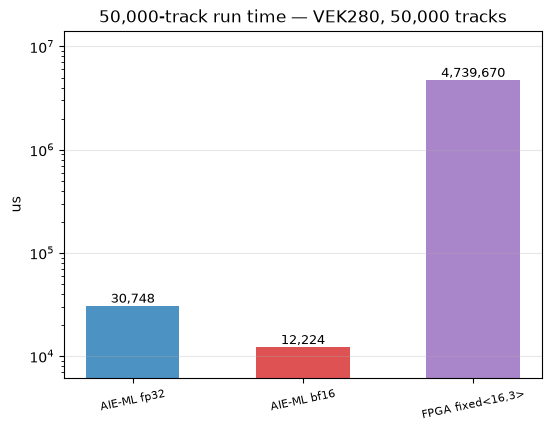

In [8]:
# Only the implementations that actually have a measured number; a bar chart
# with a nan in it silently drops the axis limits.
have = [i for i in IMPLS if perf[i]['hw_ns'] == perf[i]['hw_ns']]
if not have:
    print('no measured throughput yet -- run a board build')
else:
    panels = [('hw_ns', 'ns per track (measured)', 'ns', 'performance_ns_per_track.png')]
    if any(perf[i]['gops'] == perf[i]['gops'] for i in have):
        panels.append(('gops', 'GOP/s', 'GOP/s', 'performance_gops.png'))
    panels.append(('exec_us', '50,000-track run time', 'us', 'performance_exec_us.png'))

    x = np.arange(len(have))
    for key, title, unit, fname in panels:
        fig, ax = plt.subplots(figsize=(5.4, 4.2), constrained_layout=True)
        vals = [perf[i][key] for i in have]
        bars = ax.bar(x, vals, color=[COL[i] for i in have], alpha=.8, width=.55)
        ax.set_xticks(x)
        ax.set_xticklabels([LABEL[i] for i in have], fontsize=8, rotation=12)
        ax.set_ylabel(unit)
        ax.set_title(f'{title} — VEK280, 50,000 tracks')
        ax.grid(alpha=.3, axis='y')
        for bar, v in zip(bars, vals):
            if v == v:
                ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:,.0f}',
                        ha='center', va='bottom', fontsize=9)
        finite = [v for v in vals if v == v]
        if finite:
            ax.set_ylim(0, max(finite) * 1.18)
        # ns/track spans ~4 orders between the AIE and the PL; a linear axis
        # would render the AIE bars as invisible slivers.
        if finite and max(finite) / min(finite) > 50:
            ax.set_yscale('log'); ax.set_ylim(min(finite) * .5, max(finite) * 3)
        save_fig(fig, fname)
        plt.show()


## 5. Accuracy as a function of latency

The two previous sections measure the two axes separately: §2 says how far each
implementation sits from the reference, §4 says how fast it runs. This is the
trade-off itself — **error against time per event**, one point per
implementation, which is the question a deployment actually asks.

**The plot is in one unit: µs per event, where an event is 50 tracks.** §4
quotes ns per *track* (615 / 249 / 114,548); this section is per *event*, because
an event is the unit of work that is waited on. They are the same measurement a
factor of 50 apart, and neither is new. The figure does not carry both — the
table below prints the ns/track column and an explicit reconciliation against
`run_info.txt`, which is where a cross-check against §4 belongs.

**One operating point: the largest batch in the scan.** Numbers come from
`results/<impl>/hw/scan.csv`, which repeats every point 5 times; the median is
used. The batch size is fixed rather than chosen per implementation — picking
"whichever row was fastest" made the PL land on events=100 over events=10000 on
a 0.04% difference, which is run-to-run noise deciding what the table says.

A single event on its own costs far more per event than any of this — 542 µs
against 30 for fp32 — but that gap is the fixed per-`graph.run()` host cost being
spread over more work, not the array. It is `rtda_scan.ipynb`'s subject and is
deliberately not plotted here.

The y value is `ARITH`, the same warm-up-cancelled arithmetic error §2 selected —
not a second definition of accuracy. It does not move with batch size: the
arithmetic is identical whatever the batch, which is what the scan's constant
`mean_checksum` shows. Lower and further left is better; which implementations
nothing else beats on both axes is printed under the figure rather than drawn on
it, since with three points a frontier line reads as a trend through the data.

implementation          accuracy     latency      latency   batch   source
                        max|err|    us/event     ns/track  events
----------------------------------------------------------------------------------
  AIE-ML fp32          1.241e-06        30.1        602.9   10000   scan.csv (hw)
  AIE-ML bf16          8.001e-04        11.9        238.6   10000   scan.csv (hw)
  FPGA fixed<16,3>     3.539e-04      4733.0      94660.5   10000   scan.csv (hw)
----------------------------------------------------------------------------------

  cross-check vs §4 (run_info.txt us_per_track x 50 tracks):
    AIE-ML fp32            615.0 ns/track ->     30.7 us/event    scan     30.1   (1.02x)
    AIE-ML bf16            244.5 ns/track ->     12.2 us/event    scan     11.9   (1.02x)
    FPGA fixed<16,3>     94793.4 ns/track ->   4739.7 us/event    scan   4733.0   (1.00x)


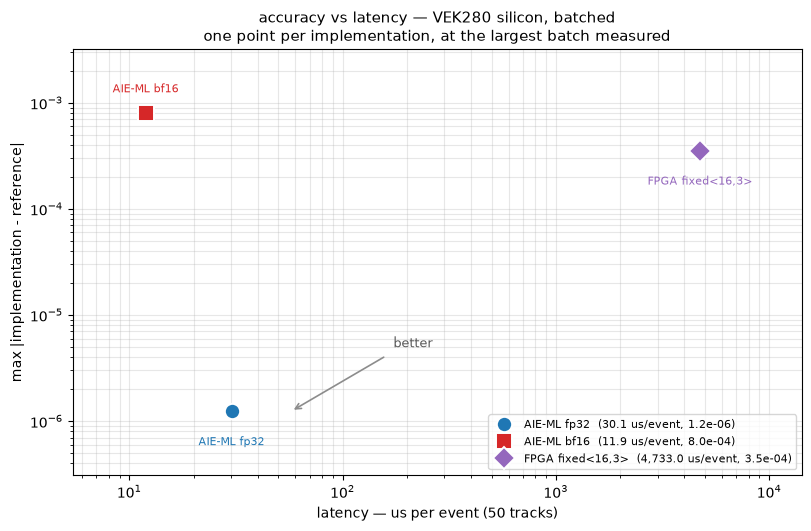


  Pareto front:  AIE-ML bf16, AIE-ML fp32
  FPGA fixed<16,3> is DOMINATED by AIE-ML fp32: 157x the latency AND 285x the error.
  Being on the front is not the same as being the right choice --
  it only means nothing else beats it on both axes at once.


In [9]:
# Accuracy against latency, at the BATCHED operating point.
#
# Two things that had to be got right here:
#
# 1. ACCURACY IS `ARITH`, the selection §2 already made -- the warm-up-cancelled
#    arithmetic error, scored against whichever reference is honest for that run
#    (ONNX 3..49, or the slot-exact streaming model). Recomputing it here against
#    the all-50 circular reference would have plotted the roll convention,
#    1.5e-02, for all three -- three points on one horizontal line, and the
#    number format would have looked irrelevant to accuracy.
#
# 2. ONE OPERATING POINT, THE LARGEST BATCH MEASURED. Not the fastest row in the
#    scan: the PL curve is flat to within run-to-run noise, so "fastest" picked
#    events=100 over events=10000 on a 0.04% difference and the table then read
#    as though the three implementations had been measured under different
#    conditions. Largest batch is a condition, not an outcome, and it puts all
#    three at the same one.
#
#    A single event costs far more per event than this -- 542 us against 30 for
#    fp32 -- but that gap is the fixed per-graph.run() host cost being amortised,
#    not the array, and it is rtda_scan.ipynb's subject. It is deliberately not
#    plotted here.
#
# us_execute, not us_total: the device phases, without the ~240 ms xclbin open
# that scan_meta.txt keeps out of the rows precisely so it cannot be amortised
# into a per-event number.
import csv as _csv

# An event is TRACKS_PER_EVENT tracks, so the two units are one factor apart.
# §4 quotes ns per TRACK; this section is per EVENT, because an event is the
# unit of work a deployment waits for. Both appear, on the plot and in the table.
us_ev_to_ns_tr = lambda u: u * 1000 / TRACKS_PER_EVENT
ns_tr_to_us_ev = lambda n: n * TRACKS_PER_EVENT / 1000

def scan_latency(impl):
    """(us per event at the largest batch, that batch size, source) from the scan.

    Repeats are collapsed by MEDIAN, matching what the scan notebook plots. At a
    given event count an implementation may have several ways to run that batch
    -- the PL's fresh/reuse, the AIE's tracks-per-call groupings -- and the
    fastest of those is taken, so the number is the best that batch size was
    measured doing.
    """
    for tgt in ('hw', 'hw_emu'):                # silicon wins; emulation is a fallback
        f = IMPL_DIR[impl] / tgt / 'scan.csv'
        if not f.exists():
            continue
        groups = collections.defaultdict(list)
        with f.open() as fh:
            for row in _csv.DictReader(fh):
                ev = int(row['events'])
                if ev <= 0:                     # events=0 is the PL tracks-per-call probe
                    continue
                try:
                    groups[(ev, row['mode'], row['tracks_per_call'])].append(
                        float(row['us_execute']))
                except ValueError:
                    continue
        per_ev = {}
        for (ev, _m, _t), v in groups.items():
            per_ev[ev] = min(per_ev.get(ev, np.inf), float(np.median(v)) / ev)
        if per_ev:
            ev_hi = max(per_ev)
            return per_ev[ev_hi], ev_hi, f'scan.csv ({tgt})'
    return None, None, None

LAT = {}
for impl in IMPLS:
    if impl not in ARITH:
        continue
    us, ev, src = scan_latency(impl)
    if us is not None:
        LAT[impl] = dict(us_ev=us, at=ev, src=src)
    elif perf[impl]['hw_ns'] == perf[impl]['hw_ns']:
        # No scan for this implementation -- fall back to the shipped run's
        # per-track number, and label where it came from.
        LAT[impl] = dict(us_ev=perf[impl]['hw_ns'] * TRACKS_PER_EVENT / 1000,
                         at=perf[impl]['n'], src='run_info.txt')

if not LAT:
    print('no latency measurement found -- run the scan hosts, PHASE 7 of RUNBOOK.md')
else:
    print(f'{"implementation":<20s} {"accuracy":>11s} {"latency":>11s} {"latency":>12s} '
          f'{"batch":>7s}   source')
    print(f'{"":<20s} {"max|err|":>11s} {"us/event":>11s} {"ns/track":>12s} '
          f'{"events":>7s}')
    print('-' * 82)
    for impl in IMPLS:
        if impl not in LAT:
            continue
        L, a = LAT[impl], ARITH[impl]
        print(f'  {LABEL[impl]:<18s} {a["worst"]:11.3e} {L["us_ev"]:11.1f} '
              f'{us_ev_to_ns_tr(L["us_ev"]):12.1f} {L["at"]:7d}   {L["src"]}')
    print('-' * 82)

    # Reconcile against §4 in §4's own units, rather than leaving the two
    # sections to be compared by eye and read as disagreeing by 50x.
    print('\n  cross-check vs §4 (run_info.txt us_per_track x 50 tracks):')
    for impl in IMPLS:
        if impl not in LAT or perf[impl]['hw_ns'] != perf[impl]['hw_ns']:
            continue
        shipped = perf[impl]['hw_ns'] * TRACKS_PER_EVENT / 1000
        print(f'    {LABEL[impl]:<18s} {perf[impl]["hw_ns"]:9.1f} ns/track ->'
              f'{shipped:9.1f} us/event    scan {LAT[impl]["us_ev"]:8.1f}'
              f'   ({shipped/LAT[impl]["us_ev"]:.2f}x)')

    # ---------------------------------------------------------------------
    # THE PARETO FRONT, computed rather than asserted. An implementation is
    # dominated when another is at least as good on BOTH axes. Written out
    # because the answer is not the one §4's bar charts suggest.
    # ---------------------------------------------------------------------
    # Computed for the printed conclusion below. It is NOT drawn: with three
    # points the line joined two of them across the whole canvas and read as a
    # trend through the data, which it is not.
    front = sorted((i for i in LAT
                    if not any(j != i and LAT[j]['us_ev'] <= LAT[i]['us_ev']
                               and ARITH[j]['worst'] <= ARITH[i]['worst']
                               for j in LAT)),
                   key=lambda i: LAT[i]['us_ev'])

    fig, ax = plt.subplots(figsize=(8, 5.2), constrained_layout=True)
    MARK = {'aie_fp32': 'o', 'aie_bf16': 's', 'pl_fixed': 'D'}   # shape, so identity
    for impl in IMPLS:                                          # survives greyscale
        if impl not in LAT:
            continue
        x, y = LAT[impl]['us_ev'], ARITH[impl]['worst']
        ax.plot(x, y, MARK[impl], ms=11, color=COL[impl], mec='white', mew=1.4,
                zorder=4,
                label=f'{LABEL[impl]}  ({x:,.1f} us/event, {y:.1e})')
        # Label ABOVE the topmost point, below the rest. The Pareto line leaves
        # each point heading down-right, so a label hung below the top-of-front
        # marker lands on the line and is read through it.
        _above = y >= max(ARITH[i]['worst'] for i in LAT)
        ax.annotate(LABEL[impl], (x, y), textcoords='offset points',
                    xytext=(0, 13 if _above else -18), ha='center',
                    va='bottom' if _above else 'top', fontsize=8, color=COL[impl])

    ax.set_xscale('log'); ax.set_yscale('log')
    # Explicit limits, not autoscale. The rightmost marker is the slowest design
    # and its direct label is the widest, so autoscale clips both at the spine.
    _xs = [LAT[i]['us_ev'] for i in LAT]
    _ys = [ARITH[i]['worst'] for i in LAT]
    ax.set_xlim(min(_xs) / 2.2, max(_xs) * 3.0)
    ax.set_ylim(min(_ys) / 4.0, max(_ys) * 4.0)
    ax.set_xlabel('latency — us per event (50 tracks)')
    ax.set_ylabel('max |implementation - reference|')
    ax.set_title(f'accuracy vs latency — VEK280 silicon, batched\n'
                 f'one point per implementation, at the largest batch measured',
                 fontsize=11)
    ax.grid(alpha=.3, which='both')
    # loc='best' put the box over the PL marker -- 'best' minimises overlap with
    # DATA, and a lone point in the top right is cheap for it to cover. The lower
    # right is empty in this design and is pinned explicitly.
    ax.legend(fontsize=8, loc='lower right')
    # Better is down-and-left, and on a log-log trade-off plot that is worth
    # saying once rather than leaving the reader to work out the polarity.
    ax.annotate('better', xy=(.44, .30), xycoords='axes fraction', fontsize=9,
                color='0.35', ha='left')
    ax.annotate('', xy=(.30, .15), xytext=(.43, .28), xycoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='0.55', lw=1.2))
    _save = globals().get('save_fig',
                          lambda f, n: f.savefig(OUTD / n, dpi=140, bbox_inches='tight'))
    _save(fig, 'accuracy_vs_latency.png')
    plt.show()

    if len(front) < len(LAT):
        print('\n  Pareto front:  ' + ', '.join(LABEL[i] for i in front))
        for i in (j for j in LAT if j not in front):
            by = min((j for j in LAT if j != i and LAT[j]['us_ev'] <= LAT[i]['us_ev']
                      and ARITH[j]['worst'] <= ARITH[i]['worst']),
                     key=lambda j: ARITH[j]['worst'])
            print(f'  {LABEL[i]} is DOMINATED by {LABEL[by]}: '
                  f'{LAT[i]["us_ev"]/LAT[by]["us_ev"]:.0f}x the latency AND '
                  f'{ARITH[i]["worst"]/ARITH[by]["worst"]:.0f}x the error.')
        print('  Being on the front is not the same as being the right choice --'
              '\n  it only means nothing else beats it on both axes at once.')

## 6. Dynamic power against latency

§5 plots error against time. This plots **power** against the same time axis, so
the third axis of the trade-off is visible next to the other two.

**Where the numbers come from.** `report_power` on each design's routed
checkpoint, saved by hand as `results/<impl>/hw/power_routed.rpt`. The
checkpoints live in `<flow>/_x/<stamp>/link/vivado/vpl/prj/prj.runs/impl_1/`.

**These are estimates, and the cell says so.** With no switching-activity file
Vivado estimates vectorlessly and stamps the report `Confidence Level: Low` for
exactly that reason. The cell reads that field and prints it rather than
presenting the number as a measurement. Treat a difference of a few hundred mW
between implementations as noise; treat a factor of two as real.

**On-chip, not board.** `report_power` covers the device. Board power includes
regulators, DDR and peripherals, and is only obtainable by measuring — the
`pmtool` capture in the repo root is a real board reading but has no record of
which design was running, so nothing here is labelled board power.

The energy column is dynamic power x latency per event: the actual cost of
processing one event, which is the quantity a power budget cares about and
neither axis shows on its own.

implementation         dynamic   static    total     latency      energy   confidence
                             W        W        W    us/event    mJ/event
------------------------------------------------------------------------------------
  AIE-ML fp32           21.733    9.552   31.285        30.1      0.6551   Low
  AIE-ML bf16           21.860    9.552   31.412        11.9      0.2608   Low
  FPGA fixed<16,3>      15.429    9.595   25.024      4733.0     73.0258   Low
------------------------------------------------------------------------------------
  energy = dynamic power x latency per event, the cost of one event.

  dynamic power by component (W)
    component                AIE-ML fp32         AIE-ML bf16    FPGA fixed<16,3>
    Clocks                         0.018               0.018               1.685
    Logic                          0.001               0.001               2.051
    Signals                        0.042               0.042               2.373
    MMC

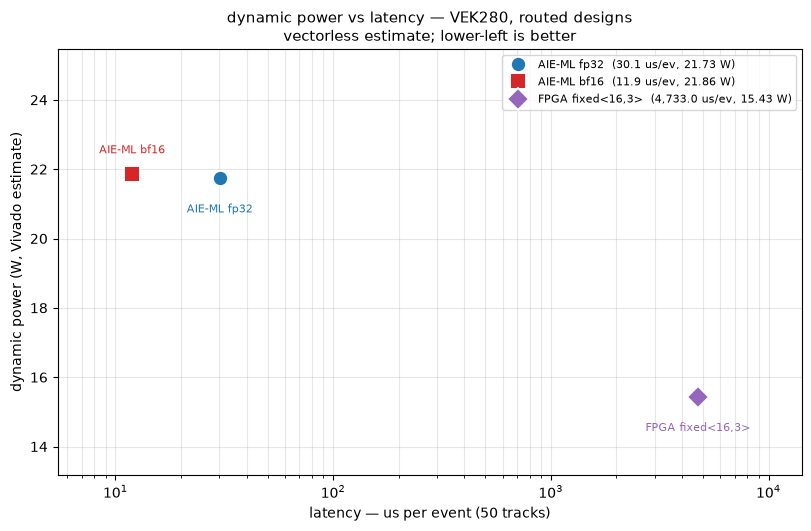

In [10]:
# Dynamic power vs latency. The latency axis is LAT from section 5 -- the same
# measured batched point, not a second selection of its own.
#
# report_power is not run here: it needs Vivado and a routed checkpoint, and it
# is a long interactive job. This reads what that job wrote.
import re as _re

POWER_RPT = 'power_routed.rpt'          # results/<impl>/hw/power_routed.rpt


def read_power(path):
    """Vivado report_power -> the summary fields, or None.

    The summary is a two-column table; every row is `| Key | Value |`. Parsing
    the table rather than fixed line offsets means a Vivado version that adds a
    row (Versal reports carry fields the 7-series ones do not) does not shift
    everything by one.
    """
    if not Path(path).exists():
        return None
    want = {'Total On-Chip Power (W)': 'total', 'Dynamic (W)': 'dynamic',
            'Device Static (W)': 'static', 'Confidence Level': 'confidence'}
    out = {}
    for ln in Path(path).read_text(errors='replace').splitlines():
        if ln.count('|') < 3:
            continue
        cells = [c.strip() for c in ln.split('|')]
        if len(cells) >= 3 and cells[1] in want:
            key, val = want[cells[1]], cells[2]
            if key == 'confidence':
                out[key] = val
            else:
                # Values carry footnote markers -- "9.552**" means Vivado used
                # worst-case Tj because no environmental constraints were set.
                # That moves STATIC power only; the dynamic figure is unaffected.
                m = _re.match(r'[-+]?[0-9]*\.?[0-9]+', val)
                if m:
                    out[key] = float(m.group(0))
    # The On-Chip Components table: where the dynamic power actually goes.
    # split(...)[-1] because '1.1 On-Chip Components' appears twice -- once in
    # the report's own table of contents and once as the section itself.
    txt = Path(path).read_text(errors='replace')
    if '1.1 On-Chip Components' in txt:
        sec = txt.split('1.1 On-Chip Components')[-1].split('1.2 Power Supply')[0]
        comp = {}
        for ln in sec.splitlines():
            raw = ln.split('|')
            if len(raw) < 4:
                continue
            # Sub-rows are indented INSIDE the cell ('|   NoC') under their
            # parent ('| NoC-DDRMC'). Summing both double-counts, so keep the
            # parents. Static Power is excluded too: this table is dynamic.
            if raw[1].startswith('   '):
                continue
            name, val = raw[1].strip(), raw[2].strip()
            if not name or name.startswith('On-Chip') or name in ('Total', 'Static Power'):
                continue
            m = _re.match(r'[-+]?[0-9]*\.?[0-9]+', val.replace('<', ''))
            if m:
                comp[name] = float(m.group(0))
        if comp:
            out['components'] = comp
    return out or None


# Everything the platform costs whatever the design does: the shim I/O, the
# NoC and memory controllers, the PS, the PLLs. Splitting it out is the
# difference between "this design draws 15 W" and "this design draws 5 W on a
# platform that draws 10 W before it starts".
PLATFORM_KEYS = ('I/O', 'NoC-DDRMC', 'PS9', 'XPLL', 'MMCM')


PWR = {}
for impl in IMPLS:
    p = read_power(IMPL_DIR[impl] / 'hw' / POWER_RPT)
    if p and 'dynamic' in p:
        PWR[impl] = p

if not PWR:
    print(f'No power reports found. Expected {POWER_RPT} in:')
    for impl in IMPLS:
        print(f'    {(IMPL_DIR[impl] / "hw" / POWER_RPT).relative_to(REPO)}')
    print("""
  Produce one per implementation, in Vivado:

      open_checkpoint <flow>/_x/<stamp>/link/vivado/vpl/prj/prj.runs/impl_1/\\
                      vitis_design_wrapper_routed.dcp
      report_power -file <that path above>

  stamps: aie_batch fp32_hw / bf16_hw, pl_fixed ap16_3_hw.""")
elif not LAT:
    print('power found, but no latency -- section 5 produced no LAT.')
else:
    have = [i for i in IMPLS if i in PWR and i in LAT]
    print(f'{"implementation":<20s} {"dynamic":>9s} {"static":>8s} {"total":>8s} '
          f'{"latency":>11s} {"energy":>11s}   confidence')
    print(f'{"":<20s} {"W":>9s} {"W":>8s} {"W":>8s} {"us/event":>11s} '
          f'{"mJ/event":>11s}')
    print('-' * 84)
    for impl in have:
        p, us = PWR[impl], LAT[impl]['us_ev']
        mj = p['dynamic'] * us / 1000.0          # W * us -> uJ, /1000 -> mJ
        print(f'  {LABEL[impl]:<18s} {p["dynamic"]:9.3f} {p.get("static", float("nan")):8.3f} '
              f'{p.get("total", float("nan")):8.3f} {us:11.1f} {mj:11.4f}   '
              f'{p.get("confidence", "?")}')
    print('-' * 84)
    print('  energy = dynamic power x latency per event, the cost of one event.')

    # WHERE the power goes. The AIE designs and the PL design spend it in
    # completely different places, and the totals alone hide that.
    keys = []
    for impl in have:
        for k in PWR[impl].get('components', {}):
            if k not in keys and k not in ('Total',):
                keys.append(k)
    if keys:
        print()
        print(f'  dynamic power by component (W)')
        print(f'    {"component":<16}' + ''.join(f'{LABEL[i]:>20s}' for i in have))
        for k in keys:
            vals = [PWR[i].get('components', {}).get(k, 0.0) for i in have]
            if max(vals) >= 0.01:
                print(f'    {k:<16}' + ''.join(f'{v:20.3f}' for v in vals))
        print()
        for impl in have:
            c = PWR[impl].get('components', {})
            plat = sum(c.get(k, 0.0) for k in PLATFORM_KEYS)
            print(f'    {LABEL[impl]:<18s} platform {plat:6.3f} W  +  design '
                  f'{PWR[impl]["dynamic"] - plat:6.3f} W')
        print('    platform = I/O + NoC/DDRMC + PS + PLLs: paid before the design runs.')

    conf = {p.get('confidence', '?') for p in PWR.values()}
    if conf - {'High'}:
        print(f'\n  Vivado confidence: {", ".join(sorted(conf))}. Vectorless estimation --'
              '\n  no switching activity file. Read these as ranking, not as measurements.')

    fig, ax = plt.subplots(figsize=(8, 5.2), constrained_layout=True)
    MARK = {'aie_fp32': 'o', 'aie_bf16': 's', 'pl_fixed': 'D'}
    for impl in have:
        x, y = LAT[impl]['us_ev'], PWR[impl]['dynamic']
        ax.plot(x, y, MARK[impl], ms=11, color=COL[impl], mec='white', mew=1.4,
                zorder=4, label=f'{LABEL[impl]}  ({x:,.1f} us/ev, {y:.2f} W)')
        _above = y >= max(PWR[i]['dynamic'] for i in have)
        ax.annotate(LABEL[impl], (x, y), textcoords='offset points',
                    xytext=(0, 13 if _above else -18), ha='center',
                    va='bottom' if _above else 'top', fontsize=8, color=COL[impl])

    ax.set_xscale('log')
    _xs = [LAT[i]['us_ev'] for i in have]
    _ys = [PWR[i]['dynamic'] for i in have]
    ax.set_xlim(min(_xs) / 2.2, max(_xs) * 3.0)
    _pad = max(0.15, (max(_ys) - min(_ys)) * 0.35)
    ax.set_ylim(max(0, min(_ys) - _pad), max(_ys) + _pad * 1.6)
    ax.set_xlabel('latency — us per event (50 tracks)')
    ax.set_ylabel('dynamic power (W, Vivado estimate)')
    ax.set_title('dynamic power vs latency — VEK280, routed designs\n'
                 'vectorless estimate; lower-left is better', fontsize=11)
    ax.grid(alpha=.3, which='both')
    ax.legend(fontsize=8, loc='best')
    _save = globals().get('save_fig',
                          lambda f, n: f.savefig(OUTD / n, dpi=140, bbox_inches='tight'))
    _save(fig, 'power_vs_latency.png')
    plt.show()

    missing = [i for i in IMPLS if i not in PWR]
    if missing:
        print('\n  no power report yet for: ' + ', '.join(LABEL[i] for i in missing))

## 7. Verdict


In [11]:
print('  27 outputs, warm-up excluded or cancelled, against a full-precision reference\n')
for impl in IMPLS:
    if impl not in ARITH:
        continue
    a = ARITH[impl]
    rel = 100 * (a['per_output'] / std).max()
    print(f'    {LABEL[impl]:<20s} {a["worst"]:.2e}   {100*a["worst"]/FS:6.3f}% of full scale'
          f'   up to {rel:5.0f}% of the narrowest output\'s spread'
          f'   ({a["n"]} events, vs {a["ref"]})')

if 'aie_bf16' in ARITH and 'pl_fixed' in ARITH:
    _nc = min(ARITH['aie_bf16']['n'], ARITH['pl_fixed']['n'])
    b = ARITH['aie_bf16']['per_event'][:_nc].max()
    p = ARITH['pl_fixed']['per_event'][:_nc].max()
    print(f"""
  BOTH ARE 16 BITS PER ACTIVATION, and over the same {_nc} event(s) the ap_fixed
  design is {b/p:.1f}x closer to the
  reference. That is not a surprise once stated: bfloat16 spends 8 bits on an
  exponent covering ~10^38, and every activation in this network lives between
  -1.8 and +1.8. ap_fixed<16,3> spends 13 bits on the mantissa of a range that
  was measured, and none on range it does not need.

  The cost is that a fixed-point format has to be matched to the network. Change
  the weights enough and <16,3> could clip, where bf16 would simply lose a
  little precision. `make sweep` reports the clipping fraction for exactly that
  reason, and the current margin is 2.2x.""")

if 'aie_fp32' in ARITH and 'aie_bf16' in ARITH:
    print(f"""
  AIE-ML bf16 vs AIE-ML fp32: {ARITH['aie_bf16']['worst']/ARITH['aie_fp32']['worst']:.0f}x less exact, for {perf['aie_fp32']['hw_ns']/perf['aie_bf16']['hw_ns']:.1f}x the speed on silicon.
  The narrow outputs are where that hurts -- up to {100*(ARITH['aie_bf16']['per_output']/std).max():.0f}% of their own spread.
  If the analysis weights all 27 equally, that number decides it; if it leans on
  the wide ones, bf16 is close to free.""")


# ---------------------------------------------------------------------------
# FIGURES WRITTEN. rtda_reference and rtda_scan both end by listing what they
# produced; this notebook did not, and that is exactly the gap that let six of
# its figures be absent from analysis/out/ without anything saying so -- the
# other two notebooks had been re-run after the directory was cleared and this
# one had not. A notebook that writes files should say which.
# ---------------------------------------------------------------------------
print('\n\n  figures written to', OUTD.relative_to(REPO))
_missing = []
for _f in FIGS:
    _p = OUTD / _f
    if _p.exists():
        print(f'    {_f:<40s} {_p.stat().st_size/1024:6.0f} KB')
    else:
        print(f'    {_f:<40s} *** NOT ON DISK ***')
        _missing.append(_f)
if _missing:
    print(f'\n  {len(_missing)} figure(s) missing -- re-run this notebook top to bottom.')
else:
    print(f'    {len(FIGS)} figures, all present.')

  27 outputs, warm-up excluded or cancelled, against a full-precision reference

    AIE-ML fp32          1.24e-06    0.001% of full scale   up to     0% of the narrowest output's spread   (1000 events, vs slot-exact)
    AIE-ML bf16          8.00e-04    0.934% of full scale   up to    11% of the narrowest output's spread   (1000 events, vs slot-exact)
    FPGA fixed<16,3>     3.54e-04    0.413% of full scale   up to     8% of the narrowest output's spread   (1000 events, vs ONNX 3..49)

  BOTH ARE 16 BITS PER ACTIVATION, and over the same 1000 event(s) the ap_fixed
  design is 2.3x closer to the
  reference. That is not a surprise once stated: bfloat16 spends 8 bits on an
  exponent covering ~10^38, and every activation in this network lives between
  -1.8 and +1.8. ap_fixed<16,3> spends 13 bits on the mantissa of a range that
  was measured, and none on range it does not need.

  The cost is that a fixed-point format has to be matched to the network. Change
  the weights enough and <

### What is not measured here

- **bf16 aiesimulator over 5 events** — only the single-event `make crosscheck` was run,
  so there is no `sim_aie_bf16_5ev_250tr.npz`. The x86 numbers stand in; x86 and
  aiesimulator agreed bit-for-bit at fp32, so this is very likely representative, but it
  is an assumption rather than a measurement.
- **Resource usage** — tiles, memory and columns come from `Map_Report.csv` / the mapper
  section of `log.<P>`, which needs a `make graph PRECISION=<P>` for each. bf16 should use
  fewer memory tiles (half the weight bytes) but the same compute tiles.
- **Warm-up-excluded accuracy on silicon** — impossible without per-track taps in the
  system build.
